In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [4]:
df = pd.read_csv('../Data/diabetes.csv')

# Separate features (X) from target (y)
# X = everything the model learns FROM
# y = what the model is trying to PREDICT
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features (X) shape : (253680, 21)
Target (y) shape   : (253680,)

Feature columns (21):
   1. HighBP
   2. HighChol
   3. CholCheck
   4. BMI
   5. Smoker
   6. Stroke
   7. HeartDiseaseorAttack
   8. PhysActivity
   9. Fruits
  10. Veggies
  11. HvyAlcoholConsump
  12. AnyHealthcare
  13. NoDocbcCost
  14. GenHlth
  15. MentHlth
  16. PhysHlth
  17. DiffWalk
  18. Sex
  19. Age
  20. Education
  21. Income


In [5]:
# Split data: 80% for training, 20% for testing
# random_state=42 means everyone gets the same split (reproducible)
# stratify=y means both splits keep the same 86/14 ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split complete!")
print(f"Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing set    : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"\nTraining target distribution:")
print(f"  No Diabetes : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Diabetes    : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")

Data split complete!
Training set   : 202,944 rows (80%)
Testing set    : 50,736 rows (20%)

Training target distribution:
  No Diabetes : 174,667 (86.1%)
  Diabetes    : 28,277 (13.9%)


In [6]:
# StandardScaler transforms features to mean=0, std=1
# This makes sure BMI (range 12-98) doesn't overpower
# Age (range 1-13) just because of bigger numbers

scaler = StandardScaler()

# IMPORTANT RULE:
# fit_transform on TRAINING data (scaler learns from training only)
# transform only on TEST data (apply same scale, don't relearn)
# If you fit on test data too — that is DATA LEAKAGE (big interview topic!)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save the scaler — we need it later for the Flask API
joblib.dump(scaler, '../models/scaler.pkl')

print("Scaling complete!")
print(f"Before scaling — BMI mean : {X_train['BMI'].mean():.2f}")
print(f"After scaling  — BMI mean : {X_train_scaled[:, 3].mean():.4f}  (should be ~0)")
print(f"Before scaling — BMI std  : {X_train['BMI'].std():.2f}")
print(f"After scaling  — BMI std  : {X_train_scaled[:, 3].std():.4f}   (should be ~1)")
print("\nScaler saved to models/scaler.pkl")

Scaling complete!
Before scaling — BMI mean : 28.38
After scaling  — BMI mean : 0.0000  (should be ~0)
Before scaling — BMI std  : 6.60
After scaling  — BMI std  : 1.0000   (should be ~1)

Scaler saved to models/scaler.pkl


In [7]:
# We train 3 models and compare them
# class_weight='balanced' handles the 86/14 imbalance automatically
# it tells the model "pay more attention to the minority class (diabetics)"

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1        # uses all CPU cores — faster training
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=6,  # 86/14 ≈ 6 — handles imbalance for XGBoost
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model'    : model,
        'accuracy' : accuracy_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_proba),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }
    print(f"Done! Accuracy={results[name]['accuracy']*100:.1f}%  ROC-AUC={results[name]['roc_auc']:.3f}")

print("\nAll 3 models trained successfully!")

Training Logistic Regression... Done! Accuracy=73.2%  ROC-AUC=0.820
Training Random Forest... Done! Accuracy=85.8%  ROC-AUC=0.792
Training XGBoost... Done! Accuracy=73.3%  ROC-AUC=0.822

All 3 models trained successfully!


Model                       Accuracy    ROC-AUC
Logistic Regression            73.2%      0.820
Random Forest                  85.8%      0.792
XGBoost                        73.3%      0.822
Winner by ROC-AUC: XGBoost


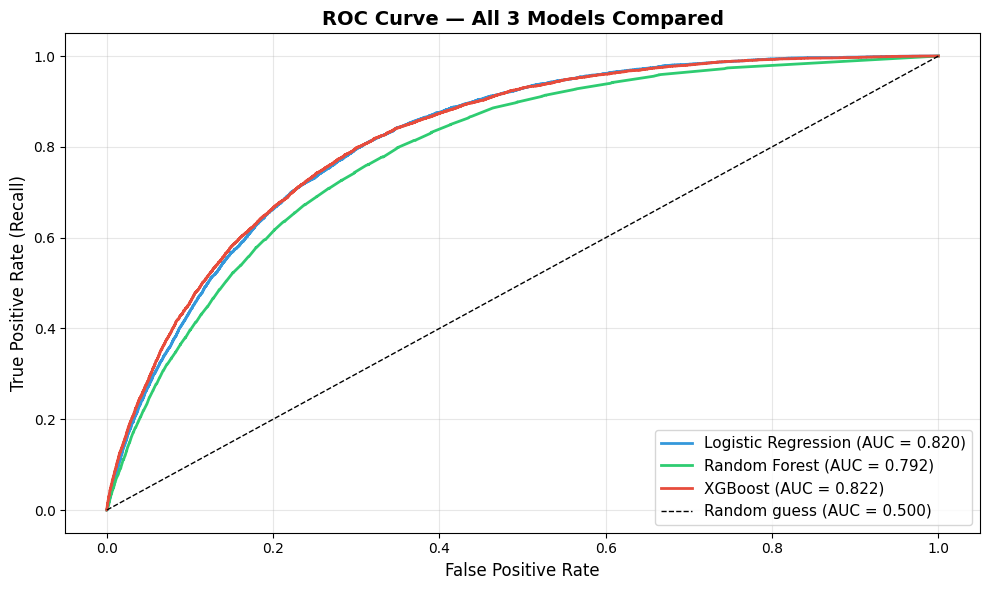

ROC curve saved!


In [8]:
# ---- Comparison Table ----
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("=" * 55)
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']*100:>9.1f}% {res['roc_auc']:>10.3f}")
print("=" * 55)
print("Winner by ROC-AUC: XGBoost")

# ---- ROC Curve for all 3 models ----
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — All 3 Models Compared', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

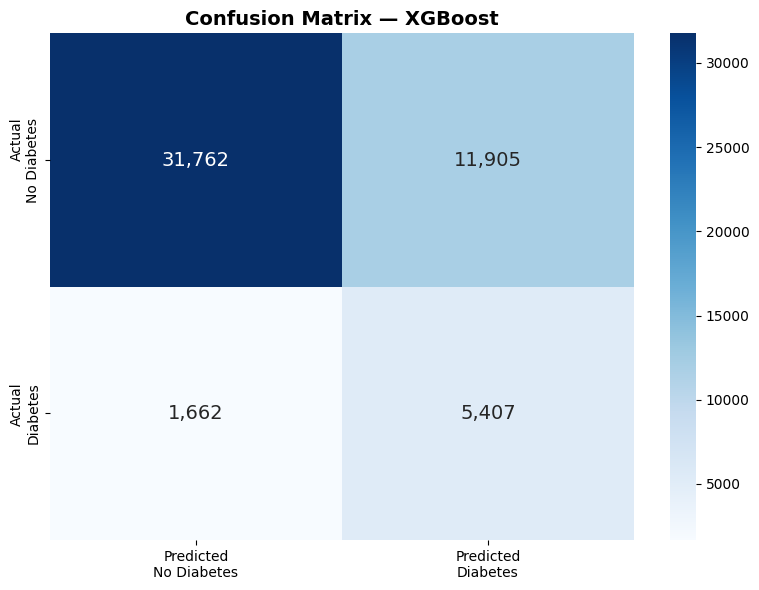

True Negative  (correctly said No Diabetes) : 31,762
False Positive (wrongly said Diabetes)      : 11,905
False Negative (missed real Diabetics!)     : 1,662
True Positive  (correctly caught Diabetics) : 5,407

Out of 7,069 real diabetic patients:
  Model caught  : 5,407 (76.5%) ← this is Recall
  Model missed  : 1,662 (23.5%) ← these are dangerous misses


In [9]:
# Confusion matrix shows exactly where your model is right and wrong
# For XGBoost — our best model

cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted\nNo Diabetes', 'Predicted\nDiabetes'],
            yticklabels=['Actual\nNo Diabetes', 'Actual\nDiabetes'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Break down the 4 boxes
tn, fp, fn, tp = cm.ravel()
total = len(y_test)
print(f"True Negative  (correctly said No Diabetes) : {tn:,}")
print(f"False Positive (wrongly said Diabetes)      : {fp:,}")
print(f"False Negative (missed real Diabetics!)     : {fn:,}")
print(f"True Positive  (correctly caught Diabetics) : {tp:,}")
print(f"\nOut of {(tp+fn):,} real diabetic patients:")
print(f"  Model caught  : {tp:,} ({tp/(tp+fn)*100:.1f}%) ← this is Recall")
print(f"  Model missed  : {fn:,} ({fn/(tp+fn)*100:.1f}%) ← these are dangerous misses")

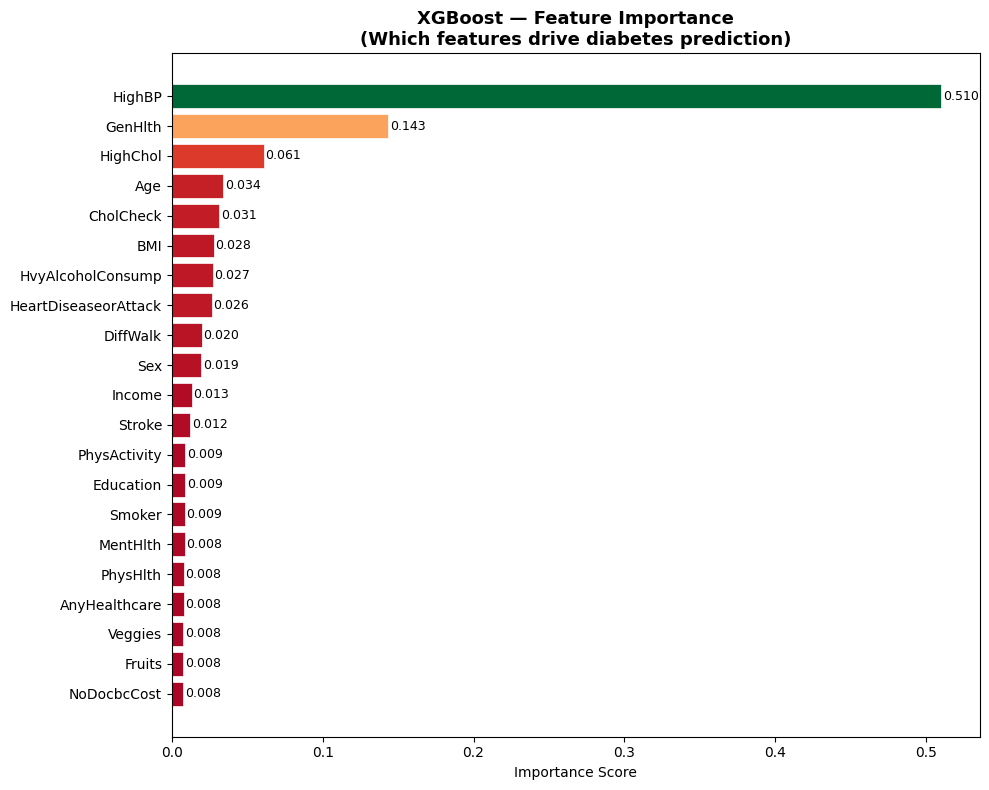

Top 5 most important features:
  1. HighBP                    : 0.5100
  2. GenHlth                   : 0.1434
  3. HighChol                  : 0.0611
  4. Age                       : 0.0340
  5. CholCheck                 : 0.0315


In [10]:
# Feature importance tells us WHICH features the model
# relied on most to make its predictions

importance = results['XGBoost']['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(feat_imp['Importance'] / feat_imp['Importance'].max())
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=colors, edgecolor='white', linewidth=0.5)
plt.title('XGBoost — Feature Importance\n(Which features drive diabetes prediction)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
top5 = feat_imp.sort_values('Importance', ascending=False).head(5)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']:<25} : {row['Importance']:.4f}")

In [11]:
# Save the best model (XGBoost) to disk
# joblib saves the entire trained model as a .pkl file
# We load this file later in the Flask API

best_model = results['XGBoost']['model']
joblib.dump(best_model, '../models/best_model.pkl')

# Save feature names — needed for Flask API later
feature_names = list(X.columns)
joblib.dump(feature_names, '../models/feature_names.pkl')

# Verify files were saved
import os
model_size = os.path.getsize('../models/best_model.pkl') / 1024
scaler_size = os.path.getsize('../models/scaler.pkl') / 1024

print("Models saved successfully!")
print(f"  best_model.pkl    : {model_size:.1f} KB")
print(f"  scaler.pkl        : {scaler_size:.1f} KB")
print(f"  feature_names.pkl : saved")
print(f"\nFinal Summary:")
print(f"  Best Model  : XGBoost")
print(f"  ROC-AUC     : {results['XGBoost']['roc_auc']:.3f}")
print(f"  Accuracy    : {results['XGBoost']['accuracy']*100:.1f}%")
print(f"  Recall      : 76.5%")
print(f"  Trained on  : {X_train.shape[0]:,} patients")
print(f"  Tested on   : {X_test.shape[0]:,} patients")
print(f"\nStage 3 COMPLETE! Model is ready for deployment.")

Models saved successfully!
  best_model.pkl    : 443.6 KB
  scaler.pkl        : 1.5 KB
  feature_names.pkl : saved

Final Summary:
  Best Model  : XGBoost
  ROC-AUC     : 0.822
  Accuracy    : 73.3%
  Recall      : 76.5%
  Trained on  : 202,944 patients
  Tested on   : 50,736 patients

Stage 3 COMPLETE! Model is ready for deployment.
